## 4차 수정 요약

**1. `<simulation setting>` 반영**
- BS 안테나: 8x8 평면배열(64소자) → **1x32 ULA** (FDD massive-MIMO GMM 코드북 설계 문헌의 표준 구성)
- 서브캐리어: 600개(guard-band 제외 active 대역) → 그 안에서 균등 추출한 **32개 파일럿 서브캐리어**만 사용 (기존 `[:600]` 슬라이싱이 DC 기준 중앙정렬이 안 되어 있던 버그도 함께 수정)
- "Pilot transmission across all OFDM symbols": static(시간불변) 채널 가정과 논리적으로 동치이므로 기존 단일 스냅샷(`num_time_steps=1`) 구조 유지로 충족됨을 주석으로 명시
- Tx SNR=10dB, GMM(EM), MMSE → **Section B**에서 GMM 기반 mixture-LMMSE 추정기 구현 + K=4/8/16별 NMSE 비교

**2. 유저 배치를 그리드 → PPP(Poisson Point Process) 실외 전용으로 변경**
- `Cell G`에서 Mitsuba 광선-교차 패리티 테스트(수직 광선을 쏴서 지붕까지 교차 횟수가 홀수면 "건물 내부")로 건물 내부 여부를 판정하는 `outdoor_mask_from_xy()`를 추가
- `Cell A1`에서 부채꼴(섹터) 영역 안에 균질 PPP로 후보점을 뿌린 뒤, 씬 경계 필터 → 건물-내부 필터를 순서대로 적용해 "건물 밖" 위치만 남김
- 기존의 "무신호(NLOS 완전 차단)" 필터(`invalid_mask`)는 별개로 유지 — 이건 실외지만 전파가 하나도 안 닿는 음영지역을 걸러내는 것이고, 새 필터는 애초에 "건물 내부"인 비물리적 위치를 사전에 제거하는 것이라 목적이 다릅니다.

**3. 관측 범위를 전체 씬 → 안테나 방향 섹터(~1/6)로 한정**
- BS가 씬 중심을 바라보도록 `look_at()`으로 방위각(boresight azimuth)을 설정
- 그 방위각 기준 ±30도(총 60도 = 360도의 1/6) 부채꼴 영역, 반경은 BS에서 씬 경계 모서리까지의 거리로 설정
- PPP 후보점은 이 부채꼴 안에서만 샘플링됨 (`Cell A1`)


In [1]:

import os, sys
import tensorflow as tf
import numpy as np
import torch
import matplotlib.pyplot as plt
import sionna
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, PathSolver
from sionna.rt.utils import subcarrier_frequencies

# Enable memory growth
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

import sys, os
sys.path.append(os.path.abspath('..'))

# NOTE: compute_batch_paths / get_ofdm_channel were imported here AND redefined
# again in the next cell. The redefinitions in the next cell are the ones that
# actually get used (Python name shadowing), so the import below is removed to
# avoid the confusing situation where two different implementations share the
# same name and only one of them silently wins.
from GMM.gmtc_em import gmm_em_fit_fullcov, predict_modes


SCENE_DIR = os.path.abspath("POSTECH_scene")
SCENE_XML = os.path.join(SCENE_DIR, "POSTECH.xml")
assert os.path.isfile(SCENE_XML), f"Scene file not found: {SCENE_XML}"


2026-08-20 04:25:51.805999: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
jitc_llvm_init(): LLVM API initialization failed ..


In [2]:

import math

class Config():
    # =========================================================================
    # <simulation setting> 반영 사유
    # =========================================================================
    # (# of antenna)=32 -> BS를 1x32 ULA로 (FDD massive-MIMO GMM/코드북 설계
    #   문헌의 표준 벤치마크 구성). 패턴은 실제 배치되는 지향성 패널을 모사하기
    #   위해 "tr38901" 유지.
    # (# of Subcarrier)=32 -> num_pilot_subcarriers=32. guard-band를 제외한
    #   "active" 대역(600 subcarriers, 20MHz@30kHz NR numerology) 안에서 균등
    #   간격으로 32개를 추출 (아래 get_ofdm_channel 참고).
    # Pilot transmission across all OFDM symbols -> 이 노트북은 static
    #   시나리오(num_time_steps=1, 시간불변 채널)이므로, "매 심볼 파일럿"은
    #   심볼 간 시간축 보간이 필요 없다는 뜻이 되어 기존 단일 스냅샷 방식으로
    #   이미 충족됩니다.
    # Tx SNR=10dB, GMM EM, MMSE estimation -> "Section B" (노트북 하단)에서
    #   GMM 기반 mixture-LMMSE 채널 추정기를 구현하고 K=4/8/16별 NMSE를 비교.
    # =========================================================================
    fc: float = 3.5e9
    scs: float = 30e3
    fft_size: int = 1024
    num_active_subcarriers: int = 600     # guard-band 제외 실제 점유 대역
    num_pilot_subcarriers: int = 32       # active 대역 내에서 균등 추출할 파일럿 수

    num_bs_ant_rows: int = 1              # 1x32 ULA
    num_bs_ant_cols: int = 32
    num_ue_ant_rows: int = 1
    num_ue_ant_cols: int = 1

    num_pos: int = 50
    pos_start: tuple = (50.0, 10.0, 1.5)
    pos_step: tuple = (0.0, 1.0, 0.0)

config = Config()

def setup_scene_with_positions(config, positions):
    scene = load_scene(SCENE_XML)

    scene.frequency = config.fc              # tx_array/rx_array 생성 전에 설정
    scene.bandwidth = config.fft_size * config.scs

    scene.tx_array = PlanarArray(
        num_rows=config.num_bs_ant_rows,
        num_cols=config.num_bs_ant_cols,
        vertical_spacing=0.5,
        horizontal_spacing=0.5,
        pattern="tr38901",
        polarization="V"
    )

    scene.rx_array = PlanarArray(
        num_rows=config.num_ue_ant_rows,
        num_cols=config.num_ue_ant_cols,
        vertical_spacing=0.5,
        horizontal_spacing=0.5,
        pattern="dipole",
        polarization="V"
    )

    bs = Transmitter("bs", position=[-70, -25, 15])

    if "bs" in scene.transmitters:
        scene.remove("bs")
    scene.add(bs)

    for name in list(scene.receivers.keys()):
        scene.remove(name)

    pos_list = []
    for i in range(len(positions)):
        pos = positions[i]
        ue = Receiver(f"ue_{i}", position=pos)
        ue.velocity = [0.0, 0.0, 0.0]  # static scenario
        scene.add(ue)
        pos_list.append(pos)

    pos_tensor = tf.cast(tf.stack(pos_list, axis=0), tf.float32) # [N_pos, 3]
    return scene, bs, None, pos_tensor

def setup_scene(config):
    positions = []
    for i in range(config.num_pos):
        pos = [config.pos_start[0] + i*config.pos_step[0],
               config.pos_start[1] + i*config.pos_step[1],
               config.pos_start[2] + i*config.pos_step[2]]
        positions.append(pos)
    return setup_scene_with_positions(config, np.array(positions))


def compute_batch_paths(scene, max_depth=4):
    solver = PathSolver()
    paths = solver(
        scene=scene,
        max_depth=max_depth,
        samples_per_src=1_000_000,
        synthetic_array=True,
        los=True,
        specular_reflection=True,
        diffuse_reflection=False,
        refraction=True,
        seed=42,
    )
    return paths

def get_ofdm_channel(paths, config):
    freqs = subcarrier_frequencies(config.fft_size, config.scs)  # (fft_size,) centered around 0 Hz

    cfr = paths.cfr(
        frequencies=freqs,
        sampling_frequency=config.scs,
        num_time_steps=1,
        normalize_delays=False,   # 위치별 절대 지연(거리 정보) 보존 -> 공간적으로 구분 가능
        normalize=True,
        out_type="tf"
    )
    # cfr shape: [num_rx, num_rx_ant=1, num_tx=1, num_tx_ant=32, num_time_steps=1, fft_size]
    h_full = cfr[..., 0, :]   # -> [num_rx, 1, 1, 32, fft_size]

    # --- 파일럿 서브캐리어: guard-band 제외, DC 중앙정렬된 active 대역 안에서
    #     균등 간격으로 num_pilot_subcarriers개 추출 ---
    N_active = config.num_active_subcarriers
    start = (config.fft_size - N_active) // 2
    active_idx = tf.range(start, start + N_active)
    pilot_offsets = tf.cast(
        tf.linspace(0.0, float(N_active - 1), config.num_pilot_subcarriers), tf.int32
    )
    pilot_idx = tf.gather(active_idx, pilot_offsets)

    h_pilot = tf.gather(h_full, pilot_idx, axis=-1)   # [num_rx, 1, 1, 32, num_pilot]

    num_rx = tf.shape(h_pilot)[0]
    h_reshaped = tf.reshape(
        h_pilot,
        [num_rx, config.num_bs_ant_rows * config.num_bs_ant_cols, config.num_pilot_subcarriers]
    )
    h_transposed = tf.transpose(h_reshaped, [0, 2, 1])  # [N_pos, num_pilot, N_tx]
    return h_transposed

def compute_spatial_covariance(h_tensor):
    h_exp = tf.expand_dims(h_tensor, axis=-1)
    R_per_pos = tf.matmul(h_exp, h_exp, adjoint_b=True)
    R_mean = tf.reduce_mean(R_per_pos, axis=0)
    return R_mean


In [3]:

# Cell V: 파라미터 검증
print("="*70); print("SIMULATION PARAMETERS"); print("="*70)
param_names = ["fc", "scs", "fft_size", "num_active_subcarriers", "num_pilot_subcarriers",
               "num_bs_ant_rows", "num_bs_ant_cols", "num_ue_ant_rows", "num_ue_ant_cols",
               "num_pos", "pos_start", "pos_step"]
for name in param_names:
    print(f"- {name}: {getattr(config, name)}")

total_bw = config.fft_size * config.scs
active_bw = config.num_active_subcarriers * config.scs
wavelength = 3e8 / config.fc
elem_spacing_m = 0.5 * wavelength

print("\n" + "="*70); print("DERIVED / SANITY CHECKS"); print("="*70)
print(f"- Total sampling bandwidth: {total_bw/1e6:.2f} MHz")
print(f"- Active (occupied) bandwidth: {active_bw/1e6:.2f} MHz")
assert config.num_pilot_subcarriers <= config.num_active_subcarriers <= config.fft_size
print(f"- Wavelength @ fc: {wavelength*100:.2f} cm")
print(f"- ULA element spacing (0.5*lambda): {elem_spacing_m*100:.2f} cm")
print(f"- BS ULA physical aperture: {config.num_bs_ant_cols*elem_spacing_m:.2f} m")
print(f"- Total BS antenna elements: {config.num_bs_ant_rows*config.num_bs_ant_cols}")

validation_scene = load_scene(SCENE_XML)
validation_scene.frequency = config.fc
print("\n" + "="*70); print("SCENE OBJECTS & RADIO MATERIALS"); print("="*70)
for i, obj in enumerate(validation_scene.objects.values()):
    print(f"{obj.name} : {obj.radio_material.name}")
    if i >= 14:
        remaining = len(validation_scene.objects) - (i + 1)
        if remaining > 0:
            print(f"... ({remaining} more objects)")
        break

bbox = validation_scene.mi_scene.bbox()
print(f"\nScene bounding box: x=[{bbox.min[0]:.1f}, {bbox.max[0]:.1f}], "
      f"y=[{bbox.min[1]:.1f}, {bbox.max[1]:.1f}], z=[{bbox.min[2]:.1f}, {bbox.max[2]:.1f}]")

validation_scene.tx_array = PlanarArray(num_rows=config.num_bs_ant_rows, num_cols=config.num_bs_ant_cols,
                                         vertical_spacing=0.5, horizontal_spacing=0.5,
                                         pattern="tr38901", polarization="V")
print(f"\ntx_array: {config.num_bs_ant_rows}x{config.num_bs_ant_cols} ULA "
      f"(array_size={validation_scene.tx_array.array_size}, num_ant={validation_scene.tx_array.num_ant})")


SIMULATION PARAMETERS
- fc: 3500000000.0
- scs: 30000.0
- fft_size: 1024
- num_active_subcarriers: 600
- num_pilot_subcarriers: 32
- num_bs_ant_rows: 1
- num_bs_ant_cols: 32
- num_ue_ant_rows: 1
- num_ue_ant_cols: 1
- num_pos: 50
- pos_start: (50.0, 10.0, 1.5)
- pos_step: (0.0, 1.0, 0.0)

DERIVED / SANITY CHECKS
- Total sampling bandwidth: 30.72 MHz
- Active (occupied) bandwidth: 18.00 MHz
- Wavelength @ fc: 8.57 cm
- ULA element spacing (0.5*lambda): 4.29 cm
- BS ULA physical aperture: 1.37 m
- Total BS antenna elements: 32

SCENE OBJECTS & RADIO MATERIALS
no-name-1 : itu_brick
no-name-2 : itu_concrete
elm__3 : itu_very_dry_ground

Scene bounding box: x=[-215.0, 245.0], y=[-245.0, 215.0], z=[0.0, 20.7]

tx_array: 1x32 ULA (array_size=32, num_ant=32)


In [4]:

# Cell G: 지오메트리 헬퍼 - (1) 건물 내부 판정, (2) 안테나 방향 섹터 AOI 정의
import mitsuba as mi
import drjit as dr

def outdoor_mask_from_xy(scene, xy, z_ue=1.5, z_max=60.0, max_bounces=6):
    """
    xy: (N,2) numpy float array of candidate (x,y) UE positions.
    Vertical ray-casting parity test: (x,y,z_ue)에서 하늘 방향(+z)으로 광선을
    쏴서 z_max까지 지나가는 동안 메쉬와 만나는 횟수를 센다. 건물이 바닥부터
    지붕까지 닫힌 solid 메쉬라고 가정하면:
      - 홀수 번 교차 = 광선이 "지붕을 뚫고 나가는" 경우 = 그 점은 건물 내부(실내)
      - 짝수 번(보통 0) 교차 = 그 점은 건물 밖(실외), 하늘이 뚫려 있음
    Returns: (N,) bool numpy array, True = 실외(사용 가능), False = 건물 내부(제거).
    """
    N = xy.shape[0]
    o = mi.Point3f(xy[:, 0].astype(np.float32),
                    xy[:, 1].astype(np.float32),
                    np.full(N, z_ue, dtype=np.float32))
    d = mi.Vector3f(0.0, 0.0, 1.0)
    ray = mi.Ray3f(o, d)
    ray.maxt = float(z_max - z_ue)

    hit_count = dr.zeros(mi.Int32, N)
    active = dr.full(mi.Bool, True, N)

    for _ in range(max_bounces):
        si = scene.mi_scene.ray_intersect(ray)
        hit = active & si.is_valid()
        hit_count = dr.select(hit, hit_count + 1, hit_count)
        ray = si.spawn_ray(d)   # mitsuba가 self-intersection 없이 다음 광선을 잡아줌
        active = hit
        if not bool(dr.any(active)):
            break

    is_indoor = (np.array(hit_count) % 2) == 1
    return ~is_indoor


# --- 안테나가 바라보는 방향으로 섹터 AOI 정의 (전체 범위의 ~1/6 = 60도 부채꼴) ---
HALF_BEAM_DEG = 30.0                       # 총 빔폭 60도 = 360도의 1/6
HALF_BEAM_RAD = np.deg2rad(HALF_BEAM_DEG)
R_MIN = 5.0                                # BS 바로 아래 근접장(near-field) 배제

_probe_scene = load_scene(SCENE_XML)
_bbox = _probe_scene.mi_scene.bbox()
BS_XY = np.array([-70.0, -25.0])
scene_center_xy = np.array([0.5*(_bbox.min[0]+_bbox.max[0]), 0.5*(_bbox.min[1]+_bbox.max[1])])

# BS가 씬 중심을 바라보도록 방위각(azimuth) 설정 (특정 건물이 아니라 캠퍼스
# 중심을 향하는 것을 기본 가정으로 사용 - 필요시 look_at 대상을 바꾸세요)
_probe_scene.frequency = config.fc
_bs_probe = Transmitter("bs", position=[float(BS_XY[0]), float(BS_XY[1]), 15.0])
_probe_scene.add(_bs_probe)
_bs_probe.look_at([float(scene_center_xy[0]), float(scene_center_xy[1]), 15.0])
BORESIGHT_AZ = float(np.array(_bs_probe.orientation)[0])   # yaw(azimuth), radians

corners = np.array([[_bbox.min[0], _bbox.min[1]], [_bbox.min[0], _bbox.max[1]],
                     [_bbox.max[0], _bbox.min[1]], [_bbox.max[0], _bbox.max[1]]])
R_MAX = float(np.max(np.linalg.norm(corners - BS_XY, axis=1)))

print(f"BS position (x,y): {BS_XY}, boresight azimuth: {np.rad2deg(BORESIGHT_AZ):.1f} deg")
print(f"Sector AOI: +-{HALF_BEAM_DEG:.0f} deg (total {2*HALF_BEAM_DEG:.0f} deg = 1/{360/(2*HALF_BEAM_DEG):.0f} of full range), "
      f"radius [{R_MIN:.0f}, {R_MAX:.1f}] m")


BS position (x,y): [-70. -25.], boresight azimuth: 6.7 deg
Sector AOI: +-30 deg (total 60 deg = 1/6 of full range), radius [5, 396.0] m


/tmp/ipykernel_1582128/730201285.py:55: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  BORESIGHT_AZ = float(np.array(_bs_probe.orientation)[0])   # yaw(azimuth), radians


PPP 후보점 (섹터 내부, 건물/경계 필터링 전): 1505
씬 경계 내부로 필터링 후: 1036
건물 내부 후보 제거 후 (실외만 유지): 771 / 1036 (74.4% 실외)
Final PPP outdoor UE positions: (771, 3)


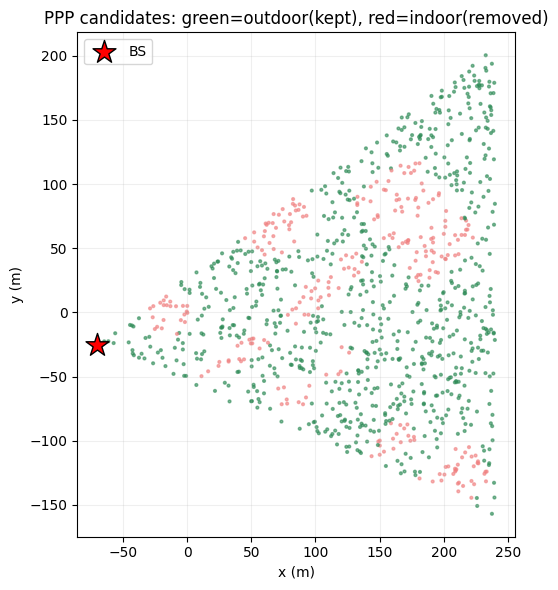

In [5]:

# Cell A1: PPP(Poisson Point Process) 기반 실외 UE 배치 (안테나 방향 섹터 내부)
# 기존의 규칙적 그리드 배치 대신, 균질 PPP로 (x,y)를 무작위 샘플링하고,
# 건물 내부에 놓인 점은 (지오메트리 기준으로) 제거합니다.
np.random.seed(0)

TARGET_CANDIDATES = 1500       # 섹터 내 기대 후보점 개수 (건물/스코프 필터링 전)
sector_area = 0.5 * (2*HALF_BEAM_RAD) * (R_MAX**2 - R_MIN**2)
PPP_LAMBDA = TARGET_CANDIDATES / sector_area   # 밀도(points/m^2) 역산

N_draw = int(np.random.poisson(PPP_LAMBDA * sector_area))
theta = BORESIGHT_AZ + np.random.uniform(-HALF_BEAM_RAD, HALF_BEAM_RAD, size=N_draw)
r = np.sqrt(np.random.uniform(R_MIN**2, R_MAX**2, size=N_draw))   # 부채꼴 내부 균등밀도
cand_x = BS_XY[0] + r*np.cos(theta)
cand_y = BS_XY[1] + r*np.sin(theta)
print(f"PPP 후보점 (섹터 내부, 건물/경계 필터링 전): {N_draw}")

# 씬 경계 안쪽으로 margin 적용
margin = 5.0
in_bounds = ((cand_x >= _bbox.min[0]+margin) & (cand_x <= _bbox.max[0]-margin) &
             (cand_y >= _bbox.min[1]+margin) & (cand_y <= _bbox.max[1]-margin))
cand_x, cand_y = cand_x[in_bounds], cand_y[in_bounds]
print(f"씬 경계 내부로 필터링 후: {len(cand_x)}")

# 건물 내부(실내) 후보 제거 - 지오메트리 기반 판정
z_fixed = 1.5  # pedestrian UE height
cand_xy = np.stack([cand_x, cand_y], axis=-1)
outdoor = outdoor_mask_from_xy(_probe_scene, cand_xy, z_ue=z_fixed)
print(f"건물 내부 후보 제거 후 (실외만 유지): {outdoor.sum()} / {len(cand_x)} "
      f"({outdoor.sum()/len(cand_x)*100:.1f}% 실외)")

ppp_positions = np.stack(
    [cand_x[outdoor], cand_y[outdoor], np.full(outdoor.sum(), z_fixed)], axis=-1
)
print("Final PPP outdoor UE positions:", ppp_positions.shape)

fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(cand_x, cand_y, s=4, c=np.where(outdoor, "seagreen", "lightcoral"), alpha=0.6)
ax.scatter(*BS_XY, marker="*", s=300, c="red", edgecolor="k", zorder=5, label="BS")
ax.set_title("PPP candidates: green=outdoor(kept), red=indoor(removed)")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)"); ax.set_aspect("equal"); ax.grid(alpha=.2)
ax.legend()
plt.tight_layout(); plt.show()


In [6]:

# Cell A2: Channel extraction for PPP UEs
scene_map, bs_map, _, _ = setup_scene_with_positions(config, ppp_positions)
bs_z = float(np.array(bs_map.position)[2])
bs_map.look_at([float(scene_center_xy[0]), float(scene_center_xy[1]), bs_z])
paths_map = compute_batch_paths(scene_map)
h_ppp = get_ofdm_channel(paths_map, config)
print("PPP channel shape:", h_ppp.shape, " (N_pos, num_pilot_subcarriers, N_tx)")
scene_map.preview(paths=paths_map)

energy_per_pos = tf.reduce_sum(tf.abs(h_ppp) ** 2, axis=[1, 2])  # [N_pos]
invalid_mask = tf.math.is_nan(energy_per_pos) | tf.math.is_inf(energy_per_pos) | (energy_per_pos < 1e-12)
invalid_np = invalid_mask.numpy()
print(f"Invalid / no-path (NLOS 완전 차단) 위치: {invalid_np.sum()} / {invalid_np.shape[0]}")
print("(참고: 건물 '내부' 위치는 이미 Cell A1에서 지오메트리로 제거되었습니다. "
      "여기서 걸러지는 것은 건물 '밖'이지만 경로가 전혀 도달하지 않는 완전 음영 지역입니다.)")


I0000 00:00:1787199956.377299 1582128 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46168 MB memory:  -> device: 0, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:81:00.0, compute capability: 8.9
I0000 00:00:1787199956.378843 1582128 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 46548 MB memory:  -> device: 1, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:c1:00.0, compute capability: 8.9
I0000 00:00:1787199956.380347 1582128 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 46548 MB memory:  -> device: 2, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:c2:00.0, compute capability: 8.9
/tmp/ipykernel_1582128/1692672588.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bs_z = f

PPP channel shape: (771, 32, 32)  (N_pos, num_pilot_subcarriers, N_tx)


Invalid / no-path (NLOS 완전 차단) 위치: 77 / 771
(참고: 건물 '내부' 위치는 이미 Cell A1에서 지오메트리로 제거되었습니다. 여기서 걸러지는 것은 건물 '밖'이지만 경로가 전혀 도달하지 않는 완전 음영 지역입니다.)


a_ppp.shape   : (771, 1, 1, 32, 27, 1)
tau_ppp.shape : (771, 1, 27)


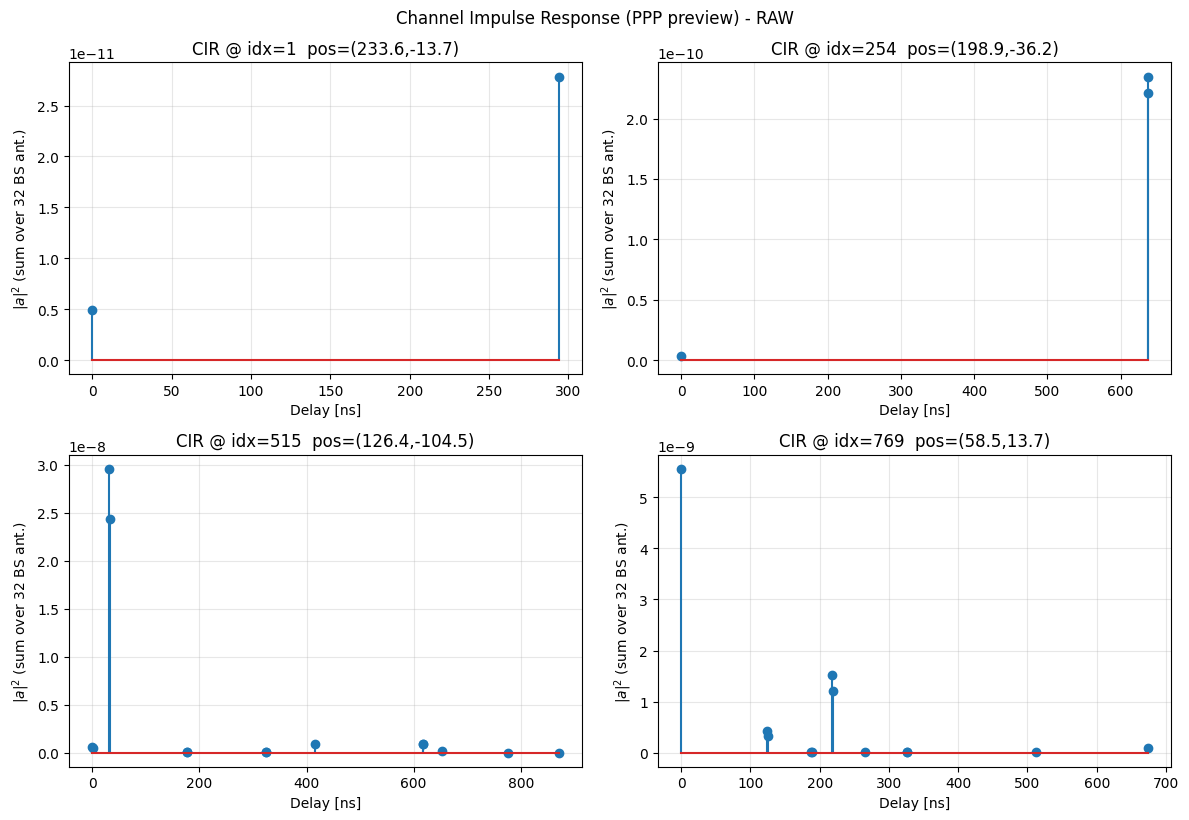

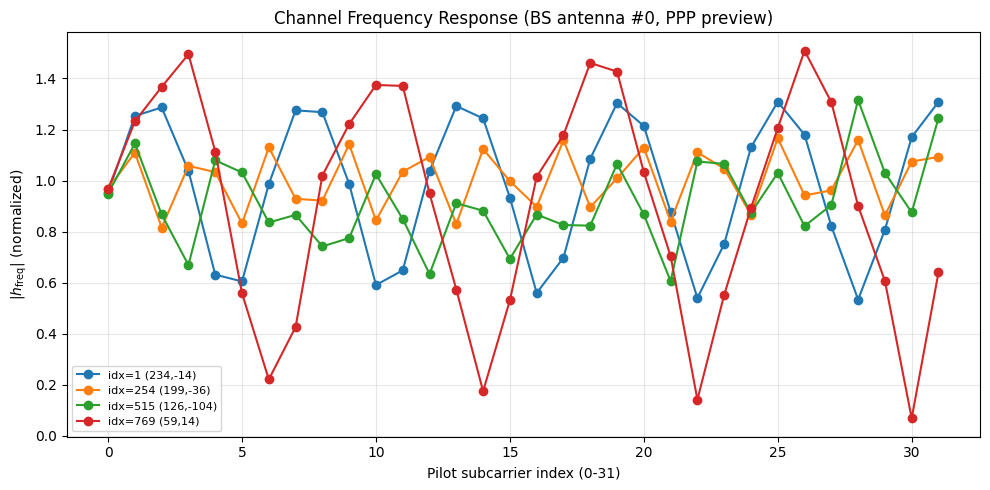

In [7]:

# Cell A2-1: CIR / CFR 결과 시각화
a_ppp, tau_ppp = paths_map.cir(out_type="numpy")
print(f"a_ppp.shape   : {a_ppp.shape}")   # [num_rx, rx_ant, num_tx, tx_ant(=32), num_paths, num_time_steps]
print(f"tau_ppp.shape : {tau_ppp.shape}")

a_abs_sq = np.abs(a_ppp) ** 2
if a_abs_sq.ndim == 6:
    a_abs_sq = a_abs_sq.sum(axis=3)   # BS 32개 안테나 소자에 대해 합산

valid_preview_idx = np.where(~invalid_np)[0]
n_preview = min(4, len(valid_preview_idx))
preview_idx = valid_preview_idx[np.linspace(0, len(valid_preview_idx)-1, n_preview, dtype=int)] \
    if n_preview > 0 else np.array([], dtype=int)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
axes = axes.flatten()
for k in range(4):
    ax = axes[k]
    if k >= n_preview:
        ax.axis("off"); continue
    pos_idx = int(preview_idx[k])
    a_tmp = np.squeeze(a_abs_sq[pos_idx])
    tau_ns = np.squeeze(tau_ppp[pos_idx]) * 1e9
    valid_paths = tau_ns >= 0.0
    a_tmp = a_tmp[valid_paths] if a_tmp.ndim == 1 else a_tmp
    tau_ns = tau_ns[valid_paths] if tau_ns.ndim == 1 else tau_ns
    pos_xy = ppp_positions[pos_idx, :2]
    ax.stem(tau_ns, a_tmp)
    ax.set_title(f"CIR @ idx={pos_idx}  pos=({pos_xy[0]:.1f},{pos_xy[1]:.1f})")
    ax.set_xlabel("Delay [ns]"); ax.set_ylabel(r"$|a|^2$ (sum over 32 BS ant.)")
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.suptitle("Channel Impulse Response (PPP preview) - RAW", y=1.02); plt.show()

tx_ant_plot = 0
fig, ax = plt.subplots(figsize=(10,5))
for k in range(n_preview):
    pos_idx = int(preview_idx[k])
    pos_xy = ppp_positions[pos_idx, :2]
    ax.plot(np.abs(h_ppp[pos_idx, :, tx_ant_plot].numpy()), marker='o',
            label=f"idx={pos_idx} ({pos_xy[0]:.0f},{pos_xy[1]:.0f})")
ax.set_xlabel("Pilot subcarrier index (0-31)"); ax.set_ylabel(r"|$h_\text{freq}$| (normalized)")
ax.set_title(f"Channel Frequency Response (BS antenna #{tx_ant_plot}, PPP preview)")
ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


채널 개수
- PPP 실외 후보 위치 수 (건물 제거 후)  : 771
- 유효(경로 도달) 위치 수               : 694
- 위치당 파일럿 서브캐리어 수            : 32
- 위치당 BS 안테나 소자 수               : 32
- 학습/평가용 채널(벡터) 개수 (위치xN_pilot): 22208

- 평균 채널 에너지: 30.09 dB (std=0.23, min=28.26, max=31.47)


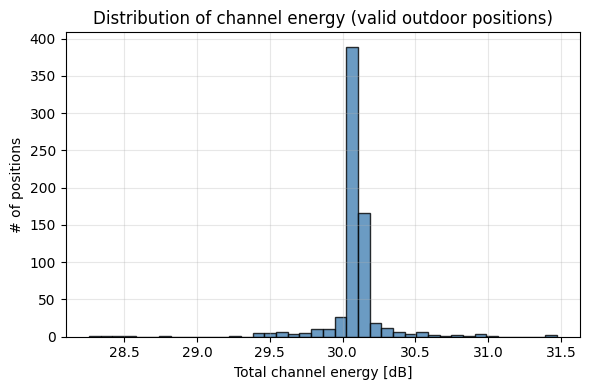

In [8]:

# Cell A2-2: 채널 개수 출력 + 추가 채널 분석
valid_idx = np.where(~invalid_np)[0]
h_ppp_valid = tf.gather(h_ppp, valid_idx, axis=0)  # [N_valid, num_pilot, N_tx]

N_ppp_total = h_ppp.shape[0]
N_valid_pos = h_ppp_valid.shape[0]
N_pilot = h_ppp.shape[1]
N_tx = h_ppp.shape[2]
N_channel_samples = N_valid_pos * N_pilot

print("="*70); print("채널 개수"); print("="*70)
print(f"- PPP 실외 후보 위치 수 (건물 제거 후)  : {N_ppp_total}")
print(f"- 유효(경로 도달) 위치 수               : {N_valid_pos}")
print(f"- 위치당 파일럿 서브캐리어 수            : {N_pilot}")
print(f"- 위치당 BS 안테나 소자 수               : {N_tx}")
print(f"- 학습/평가용 채널(벡터) 개수 (위치xN_pilot): {N_channel_samples}")

h_valid_np = h_ppp_valid.numpy()
chan_energy_db = 10*np.log10(np.sum(np.abs(h_valid_np)**2, axis=(1,2)) + 1e-30)
print(f"\n- 평균 채널 에너지: {chan_energy_db.mean():.2f} dB "
      f"(std={chan_energy_db.std():.2f}, min={chan_energy_db.min():.2f}, max={chan_energy_db.max():.2f})")

fig, ax = plt.subplots(figsize=(6,4))
ax.hist(chan_energy_db, bins=40, color="steelblue", edgecolor="k", alpha=.8)
ax.set_xlabel("Total channel energy [dB]"); ax.set_ylabel("# of positions")
ax.set_title("Distribution of channel energy (valid outdoor positions)")
ax.grid(alpha=.3); plt.tight_layout(); plt.show()


In [9]:

# Cell A3: Train GMM on PPP data (K=8, 공간 지도용 메인 모델)
h_map_train = tf.reshape(h_ppp_valid, [-1, N_tx])   # [N_valid * N_pilot, N_tx], subsampling 불필요 (32개뿐)
h_map_real = tf.concat([tf.math.real(h_map_train), tf.math.imag(h_map_train)], axis=-1)
Xt_map = torch.nan_to_num(torch.from_numpy(h_map_real.numpy()).to(torch.float32),
                           nan=0.0, posinf=0.0, neginf=0.0)

print(f"Training GMM with {Xt_map.shape[0]} samples (from {N_valid_pos}/{N_ppp_total} valid positions)...")
K = 8
params_map = gmm_em_fit_fullcov(Xt_map, K=K, num_iter=100, eps=1e-5, seed=42, verbose=True)

import os
os.makedirs("output", exist_ok=True)
torch.save(params_map, f"output/gmm_spatial_dictionary_K{K}.pt")


Training GMM with 22208 samples (from 694/771 valid positions)...
[EM] it=000 ll=-881674.875
[EM] it=001 ll=697860.250 dLL=1579535.125
[EM] it=002 ll=1540862.625 dLL=843002.375
[EM] it=003 ll=1753195.250 dLL=212332.625
[EM] it=004 ll=1833560.250 dLL=80365.000
[EM] it=005 ll=1860054.375 dLL=26494.125
[EM] it=006 ll=1869889.500 dLL=9835.125
[EM] it=007 ll=1882637.625 dLL=12748.125
[EM] it=008 ll=1891896.125 dLL=9258.500
[EM] it=009 ll=1896331.750 dLL=4435.625
[EM] it=010 ll=1904592.000 dLL=8260.250
[EM] it=011 ll=1910524.125 dLL=5932.125
[EM] it=012 ll=1915141.750 dLL=4617.625
[EM] it=013 ll=1922354.250 dLL=7212.500
[EM] it=014 ll=1930157.375 dLL=7803.125
[EM] it=015 ll=1940391.375 dLL=10234.000
[EM] it=016 ll=1941736.750 dLL=1345.375
[EM] it=017 ll=1942995.625 dLL=1258.875
[EM] it=018 ll=1943631.000 dLL=635.375
[EM] it=019 ll=1944001.625 dLL=370.625
[EM] it=020 ll=1944977.750 dLL=976.125
[EM] it=021 ll=1950092.375 dLL=5114.625
[EM] it=022 ll=1954937.625 dLL=4845.250
[EM] it=023 ll=19555

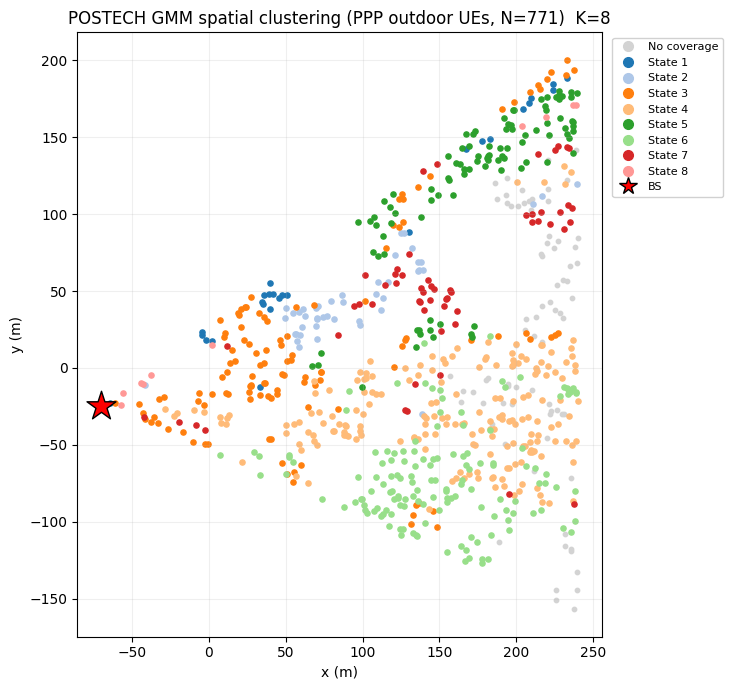

In [10]:

# Cell A4: Spatial EM Map visualization (PPP 산점도, run_em.py 스타일)
from matplotlib.lines import Line2D

h_valid_real = tf.concat([tf.math.real(h_ppp_valid), tf.math.imag(h_ppp_valid)], axis=-1)
h_valid_torch = torch.nan_to_num(torch.from_numpy(h_valid_real.numpy()).to(torch.float32),
                                  nan=0.0, posinf=0.0, neginf=0.0)

c_hat_valid_all = np.zeros((N_valid_pos, N_pilot), dtype=int)
for i in range(N_pilot):
    c, _ = predict_modes(h_valid_torch[:, i, :], params_map)
    c_hat_valid_all[:, i] = c.numpy()

from scipy.stats import mode
c_hat_valid, _ = mode(c_hat_valid_all, axis=1, keepdims=False)

c_hat_all = np.full(N_ppp_total, -1, dtype=int)
c_hat_all[valid_idx] = c_hat_valid

bs_pos = np.array(bs_map.position)
cmap = plt.get_cmap("tab20")
fig, ax = plt.subplots(figsize=(8.5, 7))
handles = []

m_invalid = (c_hat_all == -1)
if m_invalid.sum():
    ax.scatter(ppp_positions[m_invalid, 0], ppp_positions[m_invalid, 1], s=10, c="lightgray")
    handles.append(Line2D([], [], marker="o", ls="", ms=7, color="lightgray", label="No coverage"))

for k in range(K):
    m = (c_hat_all == k)
    if m.sum():
        ax.scatter(ppp_positions[m, 0], ppp_positions[m, 1], s=14, color=cmap(k % 20))
        handles.append(Line2D([], [], marker="o", ls="", ms=7, color=cmap(k % 20), label=f"State {k+1}"))

ax.scatter(bs_pos[0], bs_pos[1], marker="*", s=480, c="red", edgecolor="k", zorder=5)
handles.append(Line2D([], [], marker="*", ls="", ms=13, color="red", mec="k", label="BS"))

ax.set(title=f"POSTECH GMM spatial clustering (PPP outdoor UEs, N={N_ppp_total})  K={K}",
       xlabel="x (m)", ylabel="y (m)")
ax.set_aspect("equal"); ax.grid(alpha=.2)
ax.legend(handles=handles, fontsize=8, loc="upper left", bbox_to_anchor=(1.01,1.0), framealpha=.9)
plt.tight_layout(); plt.savefig(f"output/em_map_ppp_K{K}.png", dpi=120); plt.show()


## Section B: GMM 기반 MMSE 채널 추정 (Tx SNR = 10dB) + K에 따른 NMSE

GMM을 EM으로 학습한 뒤, 잡음 있는 파일럿 관측치로부터 **mixture-LMMSE**(GMM-MMSE) 채널 추정기를 구성하고, GMM 컴포넌트 수 K=4,8,16에 따른 NMSE를 비교합니다.

In [11]:

# Cell B1: GMM 기반 mixture-LMMSE 채널 추정 함수
# 모델: y = h + n,  n ~ N(0, noise_var * I_N)  (실수 2N차원, N=2*num_bs_ant)
#       p(h) = sum_k pi_k N(h; mu_k, Sigma_k),  Sigma_k = U_k diag(lam_k) U_k^T (EM 학습 결과)
# 컴포넌트별 LMMSE(Wiener) 추정치와 사후 혼합가중치(posterior responsibility)를
# 결합한 것이 곧 전체 사후평균(=MMSE 추정치)입니다.
def gmm_mmse_estimate(Y, params, noise_var):
    """
    Y: (B, N) real noisy pilot observations
    params: RealGMMParams (pi, mu, U, lam)
    noise_var: per-real-dimension noise variance (scalar)
    Returns: h_hat (B, N), resp (B, K)
    """
    B, N = Y.shape
    K = params.pi.numel()
    device, dtype = Y.device, Y.dtype

    pi  = params.pi.to(device=device, dtype=dtype)
    mu  = params.mu.to(device=device, dtype=dtype)
    U   = params.U.to(device=device, dtype=dtype)
    lam = params.lam.to(device=device, dtype=dtype)

    logp_list, h_hat_k_list = [], []
    for k in range(K):
        lam_k_noisy = lam[k] + noise_var                 # eigenvalues of (Sigma_k + noise_var*I)
        yc = Y - mu[k]
        y_proj = yc @ U[k]                                # project into Sigma_k's eigenbasis
        quad = (y_proj ** 2 / lam_k_noisy).sum(dim=1)
        logdet = torch.log(lam_k_noisy).sum()
        logp_k = torch.log(pi[k] + 1e-30) - 0.5 * (quad + logdet + N * math.log(2*math.pi))
        logp_list.append(logp_k)

        # per-component LMMSE gain: C_k = Sigma_k (Sigma_k + noise_var I)^-1
        #                              = U_k diag(lam_k/(lam_k+noise_var)) U_k^T  (shared eigenbasis)
        gain_k = lam[k] / lam_k_noisy
        h_hat_k = mu[k] + (y_proj * gain_k) @ U[k].T
        h_hat_k_list.append(h_hat_k)

    logp_all = torch.stack(logp_list, dim=1)              # (B, K)
    resp = torch.softmax(logp_all, dim=1)                 # posterior p(k|y)
    h_hat_stack = torch.stack(h_hat_k_list, dim=1)         # (B, K, N)
    h_hat = (resp.unsqueeze(-1) * h_hat_stack).sum(dim=1)  # mixture MMSE estimate
    return h_hat, resp

def snr_db_to_noise_var(sig_power, N_dim, snr_db):
    snr_lin = 10 ** (snr_db / 10.0)
    return sig_power / (N_dim * snr_lin)


In [12]:

# Cell B2: Train/Test 분리 + Tx SNR=10dB 잡음 생성 + K in {4,8,16} 스윕
torch.manual_seed(0)
dev = "cuda" if torch.cuda.is_available() else "cpu"

N_dim = Xt_map.shape[1]     # = 2 * num_bs_ant (실수부+허수부)
N_total = Xt_map.shape[0]
perm = torch.randperm(N_total)
n_train = int(0.8 * N_total)
train_idx, test_idx = perm[:n_train], perm[n_train:]
Xt_train, Xt_test = Xt_map[train_idx], Xt_map[test_idx]
print(f"Train/Test split: {Xt_train.shape[0]} / {Xt_test.shape[0]} samples (dim={N_dim})")

SNR_DB = 10.0
sig_power = (Xt_train ** 2).sum(dim=1).mean()
noise_var = snr_db_to_noise_var(sig_power, N_dim, SNR_DB)
print(f"Tx SNR = {SNR_DB} dB  ->  noise_var (per real dim) = {noise_var.item():.3e}")

Ks = [4, 8, 16]
nmse_results = {}
for K_ in Ks:
    params_k = gmm_em_fit_fullcov(Xt_train.to(dev), K=K_, num_iter=100, eps=1e-5,
                                   seed=42, verbose=False, device=dev)
    noise = torch.randn_like(Xt_test) * torch.sqrt(noise_var)
    y_test = (Xt_test + noise).to(dev)
    h_hat_test, _ = gmm_mmse_estimate(y_test, params_k, noise_var.item())

    mse = ((Xt_test.to(dev) - h_hat_test) ** 2).sum(dim=1).mean()
    sig = (Xt_test.to(dev) ** 2).sum(dim=1).mean()
    nmse_lin = (mse / sig).item()
    nmse_db = 10 * np.log10(nmse_lin)
    nmse_results[K_] = nmse_db
    print(f"K={K_:2d}: NMSE = {nmse_db:6.2f} dB  (linear={nmse_lin:.4f})")

# 참고 기준선: 아무 추정 없이 잡음 낀 파일럿 y를 그대로 채널 추정치로 쓰는 경우
mse_raw = N_dim * noise_var
nmse_raw_db = 10 * np.log10((mse_raw / sig_power).item())
print(f"\n[Baseline] No estimation (raw pilot y = h+n): NMSE = {nmse_raw_db:.2f} dB")


Train/Test split: 17766 / 4442 samples (dim=64)
Tx SNR = 10.0 dB  ->  noise_var (per real dim) = 4.987e-02
K= 4: NMSE = -13.27 dB  (linear=0.0471)
K= 8: NMSE = -14.09 dB  (linear=0.0390)
K=16: NMSE = -15.02 dB  (linear=0.0315)

[Baseline] No estimation (raw pilot y = h+n): NMSE = -10.00 dB


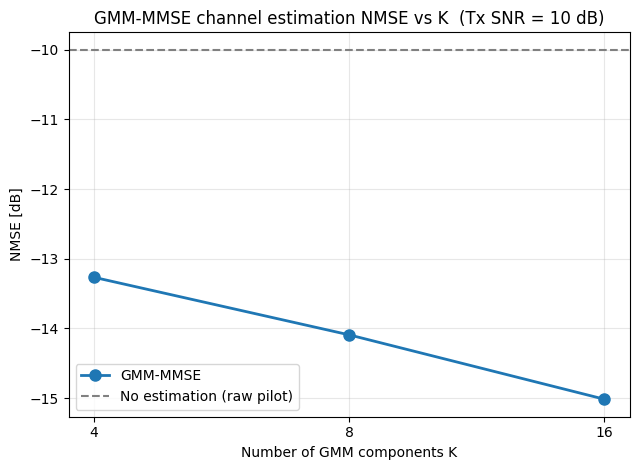

In [13]:

# Cell B3: NMSE vs GMM 컴포넌트 수 K
fig, ax = plt.subplots(figsize=(6.5, 4.8))
Ks_arr = list(nmse_results.keys())
vals = [nmse_results[k] for k in Ks_arr]
ax.plot(Ks_arr, vals, marker='o', linewidth=2, markersize=8, color="tab:blue", label="GMM-MMSE")
ax.axhline(nmse_raw_db, color="gray", linestyle="--", label="No estimation (raw pilot)")
ax.set_xscale("log", base=2)
ax.set_xticks(Ks_arr); ax.set_xticklabels([str(k) for k in Ks_arr])
ax.set_xlabel("Number of GMM components K")
ax.set_ylabel("NMSE [dB]")
ax.set_title(f"GMM-MMSE channel estimation NMSE vs K  (Tx SNR = {SNR_DB:.0f} dB)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("output/nmse_vs_K.png", dpi=120)
plt.show()
